In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))
import setup_path

In [2]:
import numpy as np
import pandas
from collections import defaultdict
import random
import time

from docplex.mp.model import Model
import cplex

from src.problems.MCLP import get_neighbors, MCLP
from src.utils.cplex_helpers import solution, cont_solution, check_feasibility, WS_parameters
from src.utils.OQUBO import DocplexModeltoQUBO, QUBOtoIsingModel
from src.utils.helpers import compute_expect, compute_cost, BruteForceSolutions

import datetime
import yfinance as yf

import qiskit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.circuit.library import efficient_su2
from qiskit.circuit import ParameterVector

In [3]:
with open("data_MCLP_.txt", "r") as file:
    instances_dict = eval(file.read())

In [4]:
def min_QAOA(model, ising_model, p, backend, LR=False, WS_params=None, iters=500):
    enrgs = []
    probs_opt = []
    def Cost_function(params, ising_model, model, quantum_circuit, backend, p, gammas, betas, LR=False, minimize=True):
        global n_iters
        
        if LR:
            gamma_vals = np.arange(1, p + 1) * params[0]/p # Annealing liear ramp schecule (cost hamiltonian)
            beta_vals = np.arange(1, p + 1)[::-1] * params[1]/p # Annealing liear ramp schedule (mixer term)
        else:
            gamma_vals = params[:p]
            beta_vals =  params[p:]
        
        bind_dict = {gammas[i]: gamma_vals[i] for i in range(len(gamma_vals))}
        bind_dict.update({betas[i]: beta_vals[i]   for i in range(len(beta_vals))})
        qc_exec = quantum_circuit.assign_parameters(bind_dict)
    
        shots = 1000
        result = backend.run(qc_exec, shots=shots).result().get_counts() 
    
        opt_sol = solution(model)
        prob_opt = result.get(opt_sol,0)/shots
        energy_qubo = compute_cost(result, ising_model)
        enrgs.append(energy_qubo)
        probs_opt.append(prob_opt)
        if minimize:
            return energy_qubo
        else: 
            return energy_qubo, result
    
    n_qubits = model.number_of_variables
    gammas = ParameterVector('γ', length=p)
    betas = ParameterVector('β', length=p)
    
    hamiltonian, ising_constant = ising_model
    
    ansatz = QuantumCircuit(n_qubits)

    if WS_params:
        for i, param in enumerate(WS_params):
            ansatz.ry(param, i)
    else:
        ansatz.h(range(n_qubits))
        
    for ii in range(p):
        for qbits, value in hamiltonian.items():
            if qbits[0] == qbits[1]:
                ansatz.rz(2*gammas[ii]*float(value), qbits[0])
        for qbits, value in hamiltonian.items():
            if qbits[0] != qbits[1]:
                ansatz.rzz(2*gammas[ii]*float(value), *qbits)
        if WS_params:
            for i, param in enumerate(WS_params):
                ansatz.ry(-param, i)
            ansatz.rz(-2*betas[ii], range(n_qubits))
            for i, param in enumerate(WS_params):
                ansatz.ry(param, i)
        else:
            ansatz.rx(-2*betas[ii], range(n_qubits))
            
    ansatz = ansatz.reverse_bits()
    ansatz.measure_all()
    gates = dict(ansatz.count_ops())
    
    # Transpile the ansatz circuit for the given backend
    qc = transpile(ansatz, backend=backend)
    
    if LR:
        delta_gamma = np.random.random() 
        delta_beta = np.random.random() 
        params = [delta_gamma, delta_beta]
        bounds_params = [(0.0000001, 0.9), (0.0000001, 0.9)] 
    else:
        gammas0 = np.random.normal(0, 1, size=p)
        betas0 = np.random.normal(0, 1, size=p)
        params = np.concatenate([gammas0, betas0])
        bounds_params = [(0.0000001, np.pi)] * (2*p)

    res = minimize(Cost_function,
            params,
            args=(ising_model, model, qc, backend, p, gammas, betas, LR),
            bounds=bounds_params,
            method="cobyla",
            options={"maxiter": iters})

    params = res.x
    f_energy, qaoa_result = Cost_function(params, ising_model, model, qc, backend, p, gammas, betas, LR, minimize=False)
    
    return res, enrgs, probs_opt, qaoa_result, f_energy, gates

In [5]:
def run_MCLP(size_grid, instances_dict, p, N, alpha, slack_vars=False, WS=False, LR=False):
    shots = 1000

    data = {}
    data['r'] = []
    data['probs'] = []
    data['success_counter'] = []
    data['qaoa_FR'] = []
    data['t_ws'] = []
    data['gates'] = []
    data['t_qaoa'] = []
    data['t_total'] = []
    data['n_fev'] = []
    data['n_qubits'] = []
    data['size_grid'] = size_grid
    data['gse'] = []
    data['qaoa_e'] = []
    data['opt_cost'] = []
    for n in size_grid:
        r_n = []
        probs_n = []
        qaoa_fes = []
        t_ws = []
        t_qaoa = []
        t = []
        n_fev = []
        gse = []
        opt_cost = []
        num_qubits = []
        qaoa_e = []
        count = 0
        print(f'{n} nodes')
        for l in range(N):
            print(f'{l} experiment')
            J = instances_dict[str(n)][l][0]
            I = instances_dict[str(n)][l][1]
            S = 1
            P = int(instances_dict[str(n)][l][2] * 0.5)
            print(f'P = {P}')
            model = MCLP(J, I, P, S, version= 'COP', slack_vars=slack_vars)
            n_qubits = model.number_of_variables
            num_qubits.append(n_qubits)
            print(model.prettyprint())
            print(f'{n_qubits} qubits')
            
        data['n_qubits'].append(num_qubits) 
        data['success_counter'].append(count/N)
        data['qaoa_FR'].append(qaoa_fes)
        data['qaoa_e'].append(qaoa_e)
        data['r'].append(r_n)
        data['probs'].append(probs_n)
        data['opt_cost'].append(opt_cost)
        data['t_ws'].append(t_ws)
        data['t_qaoa'].append(t_qaoa)
        data['t_total'].append(t)
        data['n_fev'].append(n_fev)
        data['gse'].append(gse)
    return data

In [6]:
size_grid = [[2, 2], [2, 3], [2, 4], [3, 3], [3, 4]]

p = 9
N = 10
alpha = 4

data = {}
print('UP')
data['UP'] = run_MCLP(size_grid, instances_dict, p, N, alpha, slack_vars=False, WS=False, LR=False)
print('SV')
data['SV'] = run_MCLP(size_grid, instances_dict, p, N, alpha, slack_vars=True, WS=False, LR=False)

UP
[2, 2] nodes
0 experiment
P = 1
// This file has been generated by DOcplex
// model name is: MCLP
// var contrainer section
dvar bool y[4];
dvar bool x[2];

minimize
 - 3 y_0 - 3 y_1 - 3 y_2 - y_3;
 
subject to {
 coverage_0:
  y_0 <= x_0 + x_1;
 coverage_1:
  y_1 <= x_0;
 coverage_2:
  y_2 <= x_1;
 coverage_3:
  y_3 <= x_0 + x_1;
 numspots:
  x_0 + x_1 == 1;

}
None
6 qubits
1 experiment
P = 1
// This file has been generated by DOcplex
// model name is: MCLP
// var contrainer section
dvar bool y[4];
dvar bool x[2];

minimize
 - 3 y_0 - 4 y_1 - y_2 - 5 y_3;
 
subject to {
 coverage_0:
  y_0 <= x_0 + x_1;
 coverage_1:
  y_1 <= x_0;
 coverage_2:
  y_2 <= x_1;
 coverage_3:
  y_3 <= x_0 + x_1;
 numspots:
  x_0 + x_1 == 1;

}
None
6 qubits
2 experiment
P = 1
// This file has been generated by DOcplex
// model name is: MCLP
// var contrainer section
dvar bool y[4];
dvar bool x[2];

minimize
 - 3 y_0 - 4 y_1 - 2 y_2 - 4 y_3;
 
subject to {
 coverage_0:
  y_0 <= x_0;
 coverage_1:
  y_1 <= x

In [7]:
with open(f"MCLP_n_qubits.txt", "w") as file:
    file.write(str(data))

In [8]:
labels = ['UP', 'SV']
with open(f"MCLP_n_qubits.txt", "r") as file:
    loaded_data = eval(file.read())

n_qubits = [loaded_data[label]['n_qubits'] for label in labels]
print(n_qubits)

[[[6, 6, 6, 6, 6, 6, 6, 6, 6, 6], [9, 9, 9, 9, 9, 9, 9, 9, 9, 9], [12, 12, 12, 12, 12, 12, 12, 12, 12, 12], [13, 13, 13, 13, 13, 13, 13, 13, 13, 13], [18, 18, 18, 18, 18, 18, 18, 18, 18, 18]], [[12, 12, 12, 12, 12, 12, 12, 12, 12, 12], [18, 19, 18, 20, 20, 19, 20, 19, 20, 20], [26, 27, 26, 25, 27, 26, 27, 28, 26, 24], [29, 26, 28, 28, 28, 27, 26, 28, 26, 26], [38, 40, 41, 39, 40, 41, 39, 40, 41, 40]]]


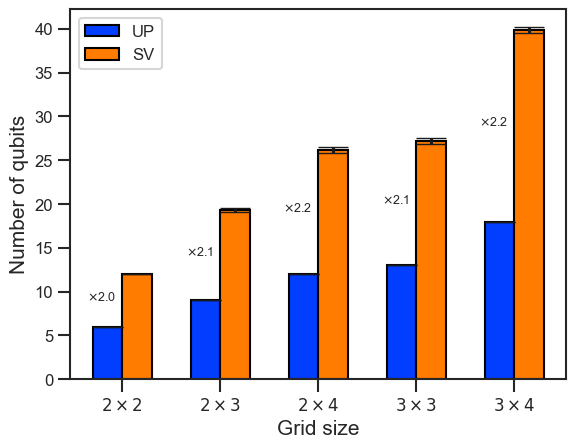

In [20]:
N_grid = [r'$2 \times 2$', r'$2 \times 3$', r'$2 \times 4 $', r'$3 \times 3$', r'$3 \times 4$']
x = np.arange(len(N_grid))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks", rc={"axes.linewidth": 1.5, 'xtick.major.width':1.5, 'ytick.major.width':1.5, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'axes.labelsize': 15}, context="talk", palette='bright')
colors = sns.color_palette('bright', n_colors=len(n_qubits))

n_series = len(labels)
width = 0.6 / n_series
y_vals_mean = []
for i, name in enumerate(labels):
    y_data = np.array(n_qubits[i])
    y_mean = np.mean(y_data, axis=1)
    y_vals_mean.append(y_mean)
    y_sem = np.std(y_data, axis=1, ddof=1) / np.sqrt(y_data.shape[1])

    offset = width*(i - (n_series - 1) / 2)
    
    plt.bar(x + offset, y_mean, yerr=y_sem, capsize=11, edgecolor='black', width=width, label=name)

gaps = [round(y_vals_mean[1][i] / y_vals_mean[0][i], 3) for i in range(len(x))]

for i, k in enumerate(x):
    plt.text(k-0.21, (y_vals_mean[1][i] - y_vals_mean[0][i])/2 + y_vals_mean[0][i], r'$\times$'+f'{gaps[i]:.1f}', ha='center', fontsize=9)
    
plt.xlabel('Grid size')
plt.ylabel('Number of qubits')
plt.xticks(x, N_grid)
plt.legend(fontsize=12)
plt.show()